<div style="font-size: 0.6em; max-width: 70ch">

# Importing packages 

</div>


In [1]:
from pathlib import Path 
import pandas as pd
from datetime import datetime
# To display the figure defined by this dict, use the low-level 
# plotly.io.show function
import plotly.io as pio
import plotly.express as px
# Using "png" to display the figures as static images in the notebook.
pio.renderers.default = "png" 

# The following lines are required to avoid an error related to the 
# MutableMapping class in the collections module, which is used by the 
# FlowCytometryTools library. This error can occur in Python 3.10 and later 
# versions, where MutableMapping has been moved to the collections.abc module. 
# By adding this code, we ensure that MutableMapping is available in the 
# collections module, allowing FlowCytometryTools to function properly.
import collections
from collections.abc import MutableMapping
if not hasattr(collections, "MutableMapping"):
    collections.MutableMapping = MutableMapping

# importing the custom modules of the project
import fcm_core.fcm as fcm
import fcm_core.fcs as fcs

# Set the display options for pandas to show all columns and rows in the output.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

<div style="font-size: 0.6em; max-width: 100ch">

# Importing and cleaning of the primary raw data

</div>


In [2]:
data_folder = "data/sample_fcs" 
df = fcm.compile_fcs_data(
    data_folder=data_folder,
    sample_name_map={
        "control -":  "Control",
        "leftover":   "Dye control",
        "dye":        "Dye control",
        "high":       "High",
        "low":        "Low",
        "parental":   "Parental",
    },
)

print(f"Total number of cells = {len(df)}")

Looking for data in: C:\Users\ardal\Desktop\notebooks for GitHub\flowcytometry-graph-gen\data\sample_fcs

Processed files
------------------------------
File name: 22jun2023 -PNT2C2 parental_PKH26- EV -DAPI_live (DAPI)_001.fcs
File name: 22jun2023 -PNT2C2 unsorted_control -DAPI_001_live (DAPI)_001.fcs
File name: 22jun2023 -PNT2C2 unsorted_PKH26- EV -DAPI_sort PKH26 high 10perc_001.fcs
File name: 22jun2023 -PNT2C2 unsorted_PKH26- EV -DAPI_sort PKH26 low 10perc_001.fcs
File name: 3jul2023 -PNT2C2 unsorted_control -DAPI_001_001.fcs
File name: 3jul2023 -PNT2C2 unsorted_control leftover dye_002.fcs
File name: 3jul2023 -PNT2C2 unsorted_PKH26 high- EV -DAPI_001_004.fcs
File name: 3jul2023 -PNT2C2 unsorted_PKH26 low- EV -DAPI_003.fcs
File name: 12jul2023 -PNT2C2_control -DAPI_001_001.fcs
File name: 12jul2023 -PNT2C2_control leftover dye_002.fcs
File name: 12jul2023 -PNT2C2_PKH26 high- EV -DAPI_001_004.fcs
File name: 12jul2023 -PNT2C2_PKH26 low- EV -DAPI_003.fcs
File name: 27jul2023 -PNT2C2_con

In [3]:
df.head(5)

,Sample,Incubation_duration,Date,File name,FSC-A,FSC-H,FSC-W,SSC-A,SSC-H,SSC-W,PKH67,Hoechst-A,BV510-A,PKH26,mCherry-A,Time,FITC-A,YG-PE-A
0,Parental,Unknown,01_22jun2023- PKH26,22jun2023 -PNT2C2 parental_PKH26- EV -DAPI_liv...,105834.960938,35244.0,196799.468750,93395.531250,37308.0,164060.515625,298.919983,345.920013,4456.540039,8895.980469,4231.850098,53.000000,NaN,NaN
1,Parental,Unknown,01_22jun2023- PKH26,22jun2023 -PNT2C2 parental_PKH26- EV -DAPI_liv...,91398.781250,41756.0,143450.312500,72445.695312,37036.0,128194.218750,145.219986,166.380005,1985.280029,4608.490234,2181.730225,54.000000,NaN,NaN
2,Parental,Unknown,01_22jun2023- PKH26,22jun2023 -PNT2C2 parental_PKH26- EV -DAPI_liv...,120642.390625,40019.0,197566.640625,103961.617188,40871.0,166700.812500,235.319992,306.440002,3915.100098,10467.810547,4831.050293,54.099998,NaN,NaN
3,Parental,Unknown,01_22jun2023- PKH26,22jun2023 -PNT2C2 parental_PKH26- EV -DAPI_liv...,125178.570312,43622.0,188063.437500,102566.656250,41490.0,162010.328125,287.259979,282.940002,3412.199951,8257.190430,4059.580078,54.400002,NaN,NaN
4,Parental,Unknown,01_22jun2023- PKH26,22jun2023 -PNT2C2 parental_PKH26- EV -DAPI_liv...,84889.531250,33213.0,167504.296875,54533.816406,24377.0,146610.656250,181.259995,231.240005,2620.719971,3414.370117,1582.530029,54.900002,NaN,NaN


In [4]:
# The two first letter of the date of the experiment are the number of the 
# experiment. We can use that for accessing certain experiment. 
df["Experimental_ID"] = df["Date"].apply(lambda x: x[0:2])

In [5]:
# Add the date of the experiment to a new column. This will be later used for 
# labelling the graphs.  # The date of the experiment is located just before 
# the first "-". Therefore, we can split at dash locations and take the first 
# item, which will be the date.  
df["Date_of_experiment"] = df["File name"].apply(lambda x: x.split("-")[0])

# There should be 11 different experiments.
df["Experimental_ID"].unique()

array(['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11'],
      dtype=object)

In [6]:
# Different sub-population which were made for each sample. 
df["Sample"].unique()

array(['Parental', 'Control', 'High', 'Low', 'Dye control'], dtype=object)

<div style="font-size: 0.6em; max-width: 100ch">

# Remove the dye control 

</div>

Dye control was used for just quality control and we don't want to include it 
in the graphs.

In [7]:
df = df.loc[~ (df["Sample"] == "Dye control")]

In [8]:
# If needed, remove certain samples based on the order of the experiments.
#df = df.loc[~ (df["Experimental_ID"] == 4)]

<div style="font-size: 0.6em; max-width: 100ch">

# Checking cell number

</div>

If the cell numbers are variable we need to normalize the sample size.



In [9]:
# See an overview of the number of cells in each sample of each experiment.
fcm.get_sample_lengths(df, "Control", "Low", "High", "Parental")


Experiment  length_of_control  length_of_low  length_of_high  length_of_parental
        01               7415            914             999                9106
        02              12000          12000           12000                   0
        03              10000          10540           10044                   0
        04              10000          12000           10000                   0
        05              15646          12000           10000                   0
        06              10000          12000           10000                   0
        07              10000          12000           10000                   0
        08               8408           9574            6590                7254
        09               8691           8656           10028                7520
        10               7524           9269            5982                5369
        11               9044          10616            7450                8497


<div style="font-size: 0.6em; max-width: 100ch">

# Normalize the sample size

</div>


In [10]:
normalized_dfs = []
for exp in df["Experimental_ID"].unique():
    exp_df = df.loc[df["Experimental_ID"] == exp]
    df_normalize = fcm.sample_size_normalizer(exp_df, "Sample", 10000, "PKH26")
    normalized_dfs.append(df_normalize)

# Make a new df from all the normalized slices. It overwrites the original df.
df = pd.concat(normalized_dfs)

<div style="font-size: 0.6em; max-width: 100ch">

# Day count for each experiment 

</div>


In [11]:
# Generate datetime objects that can be substracted from each other
date1 = datetime(2023, 6, 22)
date2 = datetime(2023, 7, 3)
date3 = datetime(2023, 7, 12)
date4 = datetime(2023, 7, 27) 
date5 = datetime(2023, 8, 4)
date6 = datetime(2023, 8, 11)
date7 = datetime(2023, 8, 21)
date8 = datetime(2023, 9, 7)
date9 = datetime(2023, 9, 18)
date10 = datetime(2023, 10, 19)
date11 = datetime(2023, 11, 20)

In [12]:
# Calculate the day number in relation to the beginning of the experiment (day 1)
all_dates = [date1, date2, date3, date4, date5, date6, date7, date8, date9, date10, date11]
all_days =[]
for i, date in enumerate(all_dates):
    if i>0: # start from the second date (index 1)
        day = abs((all_dates[i] - all_dates[0]).days)
        i += 1
        all_days.append(day)
    else: 
        pass
all_days.insert(0, 0) # Consider the first experiment as day 1 and add to the beginning of the list. 
all_days # Show all the calculated days.

# Add the calculated dates to the dataframe
# df["Days"] = all_days

[0, 11, 20, 35, 43, 50, 60, 77, 88, 119, 151]

In [13]:
# Create a mapping of Experimental_ID to days
exp_id_to_days = dict(zip(df["Experimental_ID"].unique(), all_days))
    
# Add the "Days" column to the dataframe
df["Days"] = df["Experimental_ID"].map(exp_id_to_days)

In [14]:
# Add the dates to the title of the histograms 
date_list = df["Date_of_experiment"].to_list()
day_list = df["Days"].to_list()

In [15]:
# Make a dictionary from the date_list and day_list 
day_date_dict = {a:b for a,b in zip(date_list, day_list)}

In [16]:
# Make a new column in the df with a string indicating the day of the experiment. 
df['Day'] = df['Date_of_experiment'].apply(lambda x: "Day " + str(day_date_dict[x]) if x in day_date_dict else "Day " + str(0))

In [17]:
# Select what samo;e you want to include. 
selected_df = df.loc[~ (
                        (df["Sample"].str.contains("Parental"))
                            &
                        (df["Day"]!= "Day 0")
)]

<div style="font-size: 0.6em; max-width: 100ch">

# Data visualization

</div>

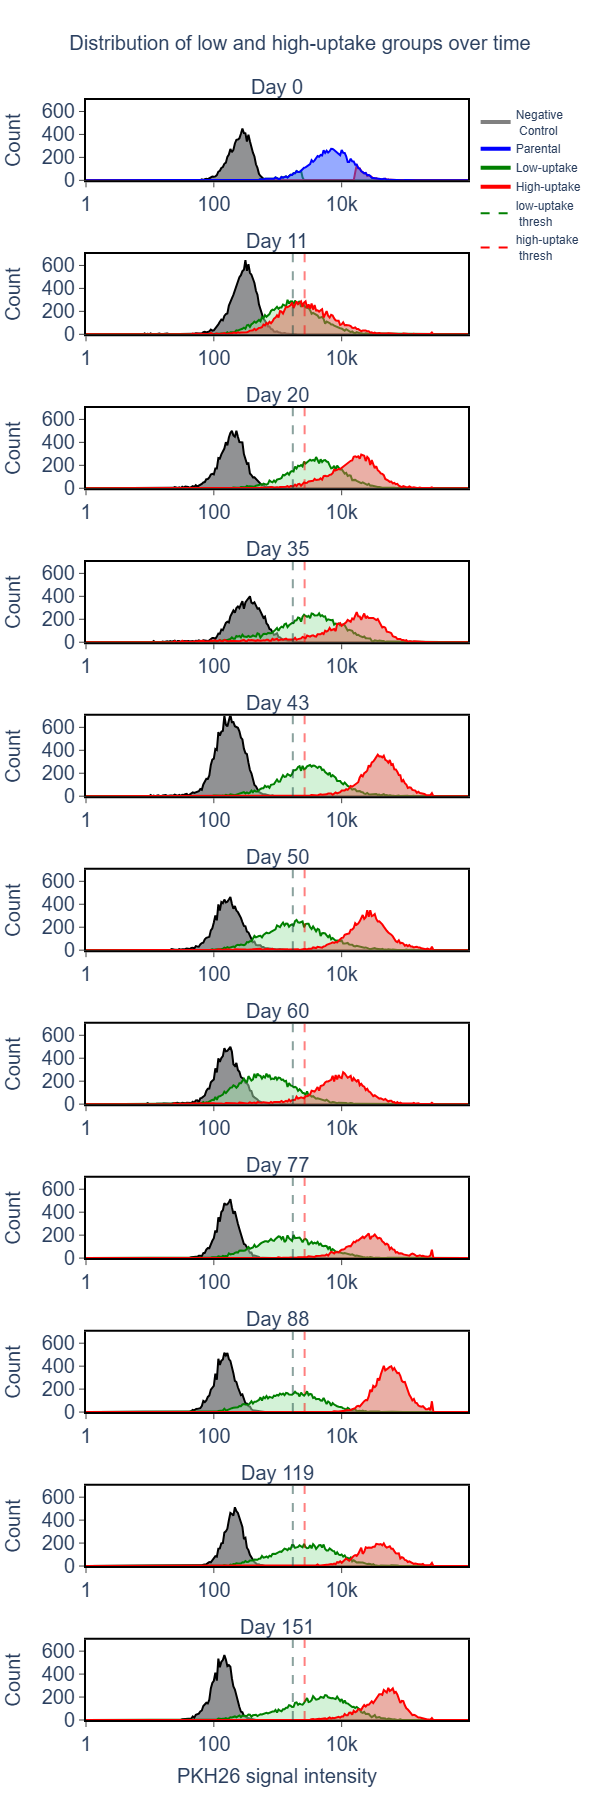

In [18]:
fig = fcs.fcs_time_scatter_plot(selected_df, df)
fig.show()  # remove hashtag to see the graph in the notebook

# Export the figs
# fig.write_image(r"C:\Users\ardal\Desktop\facs_time_scatter_plot.svg")

In [19]:
df.head()

,Sample,Incubation_duration,Date,File name,FSC-A,FSC-H,FSC-W,SSC-A,SSC-H,SSC-W,PKH67,Hoechst-A,BV510-A,PKH26,mCherry-A,Time,FITC-A,YG-PE-A,Experimental_ID,Date_of_experiment,Size_normalized_PKH26,Days,Day
0,Parental,Unknown,01_22jun2023- PKH26,22jun2023 -PNT2C2 parental_PKH26- EV -DAPI_liv...,105834.960938,35244.0,196799.468750,93395.531250,37308.0,164060.515625,298.919983,345.920013,4456.540039,8895.980469,4231.850098,53.000000,NaN,NaN,01,22jun2023,9769.361376,0,Day 0
1,Parental,Unknown,01_22jun2023- PKH26,22jun2023 -PNT2C2 parental_PKH26- EV -DAPI_liv...,91398.781250,41756.0,143450.312500,72445.695312,37036.0,128194.218750,145.219986,166.380005,1985.280029,4608.490234,2181.730225,54.000000,NaN,NaN,01,22jun2023,5060.938101,0,Day 0
2,Parental,Unknown,01_22jun2023- PKH26,22jun2023 -PNT2C2 parental_PKH26- EV -DAPI_liv...,120642.390625,40019.0,197566.640625,103961.617188,40871.0,166700.812500,235.319992,306.440002,3915.100098,10467.810547,4831.050293,54.099998,NaN,NaN,01,22jun2023,11495.509057,0,Day 0
3,Parental,Unknown,01_22jun2023- PKH26,22jun2023 -PNT2C2 parental_PKH26- EV -DAPI_liv...,125178.570312,43622.0,188063.437500,102566.656250,41490.0,162010.328125,287.259979,282.940002,3412.199951,8257.190430,4059.580078,54.400002,NaN,NaN,01,22jun2023,9067.856830,0,Day 0
4,Parental,Unknown,01_22jun2023- PKH26,22jun2023 -PNT2C2 parental_PKH26- EV -DAPI_liv...,84889.531250,33213.0,167504.296875,54533.816406,24377.0,146610.656250,181.259995,231.240005,2620.719971,3414.370117,1582.530029,54.900002,NaN,NaN,01,22jun2023,3749.582821,0,Day 0



<div style="font-size: 0.6em; max-width: 100ch">

# Line Graph for the ratio of High to low uptake 

</div>

The ratio is calculated as (Median of High uptake) / (Median of Low uptake) for each time point and experiment, based on the values of the PKH26 channel. This ratio provides insights into the relative abundance of high and low uptake populations over time.


In [20]:
# Add "1" integer to each row to be able to count the samples
df["cell_count"] = 1

# Calculate median of the PKH26 for each sample in each experiment. 
medians = df.groupby(
    by=["Experimental_ID", "Sample", "File name", "Date_of_experiment", "Days"]
).agg({"PKH26": "median", "cell_count": "sum"}).reset_index() 

In [21]:
# remove the dye sample from the dataframe
medians = medians.loc[~(medians["Sample"].str.contains("Dye"))] 

# Just in case the experiments are not in order of oldest to newest, 
# we use sort. 
medians.sort_values(by="Experimental_ID", inplace=True) 

In [22]:
"""
Make a list of unique IDs from experiment_ID.
Use their index as the time points, starting from zero. 
In order to make a new column with the values, the length of the list should 
be identifcal to the whole dataframe. Therefore, for each experiment, make a 
list the same length as the samples of that experiments and use the same 
replicates of index. Unpack the generate lists to one single list and make a 
df column from it. """

time_points_list = [
    len(medians.loc[medians["Experimental_ID"] == value]) * [i] for i, 
    value in enumerate(medians["Experimental_ID"].unique())
]
time_points =  [value + 1 for lists in time_points_list for value in lists ]

medians["Time point"] = time_points 

In [23]:
all_medians = [] 
for exp in medians["Experimental_ID"].unique():
    data = medians.loc[medians["Experimental_ID"] == exp]
 
    # As we only iloc we can perform mathematical calculation as it return an integer-based row, we first \ 
    # get the row based on the labels and then get the index of those rows for iloc. 
    row1 = data.loc[data["Sample"] == "Low"] 
    row2 = data.loc[data["Sample"] == "High"] 
    # calculate the division of the two rows
    col = 'PKH26'
    result = row2[col].values[0] / row1[col].values[0]

    # create a new row with the result of the division
    new_row = row2.copy()
    new_row[col] = result
  
    new_row["Sample"] = "High/Low ratio"
     
    data = pd.concat([data,new_row],ignore_index=True)
    data = data.loc[data["Sample"] == "High/Low ratio"]
    data.rename(columns={"PKH26": "PKH26_ratio"}, inplace=True)
    all_medians.append(data)
df_median_ratios = pd.concat(all_medians)

# Change the ratio of the first sorting to zero because we separated the 
# populations for the first time
df_median_ratios.loc[0, "PKH26_ratio"] = 0

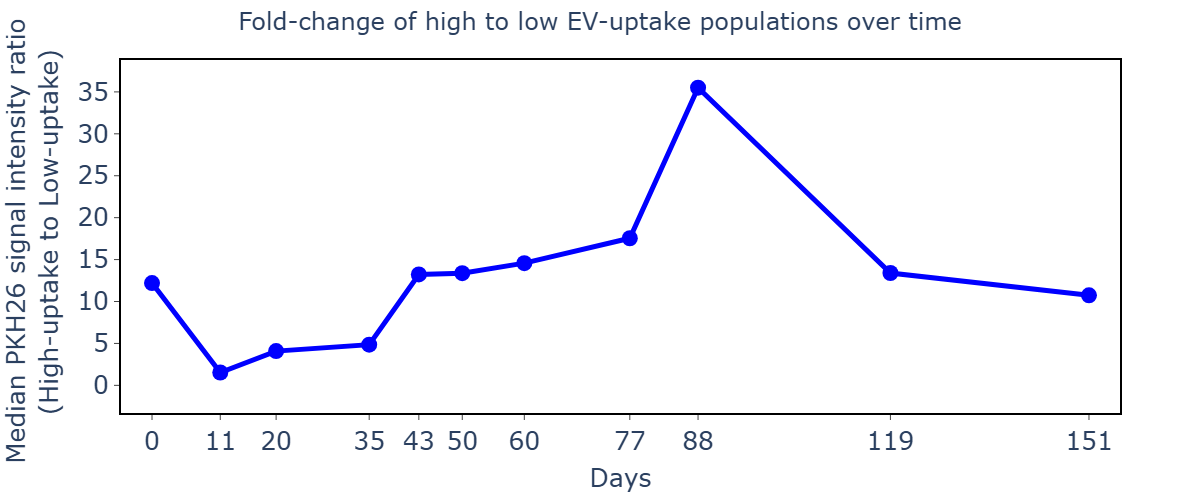

In [24]:
on_graph_text = False

if on_graph_text:
    fig = px.line(df_median_ratios, x="Days" , y="PKH26_ratio", markers=True, 
                  text="Date_of_experiment", hover_data=["cell_count"]
    ) 
else:
    fig = px.line(df_median_ratios, x="Days" , y="PKH26_ratio", markers=True, 
                  hover_data=["cell_count"]) 

# Make a box around the figure and define the range of x and y axes.
fig.update_xaxes(
    showline=True, linewidth=2, linecolor='black', mirror=True, 
    ticks="outside", title_text="Days", tick0= 1, dtick=1, 
    range=[-5, df_median_ratios["Days"].max() + 5],
    tickfont_size=25, title_font_size=25, 
)

fig.update_xaxes(tickvals=df_median_ratios['Days'][0:])

# Hide the value 0 on the axis but keep the value.
# fig.update_xaxes(tickvals=list(range(1,51))) 

fig.update_yaxes(
    showline=True, linewidth=2, linecolor='black', mirror=True, 
    ticks="outside", 
    title_text=("Median PKH26 signal intensity ratio <br> "
    "(High-uptake to Low-uptake)"
    ),
    tickfont_size=25, title_font_size=25
)

fig.update_layout(
    plot_bgcolor="white", 
    title=dict(
        text="Fold-change of high to low EV-uptake populations over time", 
        x=0.5, font_size=24
    )
)

# This list is used only if the on_graph_text is True. It defines the position 
# of the text labels for each point on the graph.
textposition = [
    "top center", "top center", "top center", "bottom center", 
    "bottom left", "top center", "top center", "bottom center", "top center", 
    "top right", "top center"
]

# change the size of the line and markers (nodes)
fig.update_traces(
    line=dict(color="blue", width=5), marker=dict(size=16),
    textposition=textposition, textfont_size=14 # if on_graph_text is True 
) 

# Image size
fig.update_layout(height=500, width=1200,)
fig.write_image(r"C:\Users\ardal\Desktop\FACS medians over time.svg") 
fig.show()

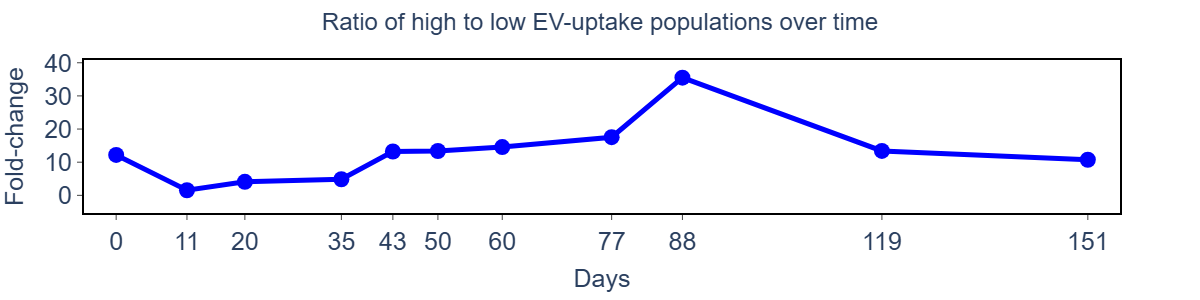

In [25]:
on_graph_text = False

if on_graph_text:
    fig = px.line(df_median_ratios, x="Days" , y="PKH26_ratio", markers=True, 
                  text="Date_of_experiment", hover_data=["cell_count"]
    ) 
else:
    fig = px.line(df_median_ratios, x="Days" , y="PKH26_ratio", markers=True, 
                  hover_data=["cell_count"]) 

# Make a box around the figure and define the range of x and y axes.
fig.update_xaxes(
    showline=True, linewidth=2, linecolor='black', mirror=True, 
    ticks="outside", title_text="Days", tick0= 1, dtick=1, 
    range=[-5, df_median_ratios["Days"].max() + 5],
    tickfont_size=25, title_font_size=25, 
    tickvals=df_median_ratios['Days'][0:], 
    showgrid=False
)

# Hide the value 0 on the axis but keep the value.
# fig.update_xaxes(tickvals=list(range(1,51))) 

fig.update_yaxes(
    showline=True, linewidth=2, linecolor='black', mirror=True, 
    ticks="outside", 
    title_text=(
        "Fold-change"
    ),
    tickfont_size=25, title_font_size=25,
    showgrid=False
)

fig.update_layout(
    plot_bgcolor="white", 
    title=dict(
        text="Ratio of high to low EV-uptake populations over time", 
        x=0.5, font_size=24
    )
)

# This list is used only if the on_graph_text is True. It defines the position 
# of the text labels for each point on the graph.
textposition = [
    "top center", "top center", "top center", "bottom center", 
    "bottom left", "top center", "top center", "bottom center", "top center", 
    "top right", "top center"
]

# change the size of the line and markers (nodes)
fig.update_traces(
    line=dict(color="blue", width=5), marker=dict(size=16),
    textposition=textposition, textfont_size=14 # if on_graph_text is True 
) 

# Image size
fig.update_layout(
    height=300, width=1200,
    font=dict(
            family="Arial"
    )
)
fig.write_image(r"C:\Users\ardal\Desktop\FACS medians over time.svg") 
fig.show()

# Lineplot for each group over time

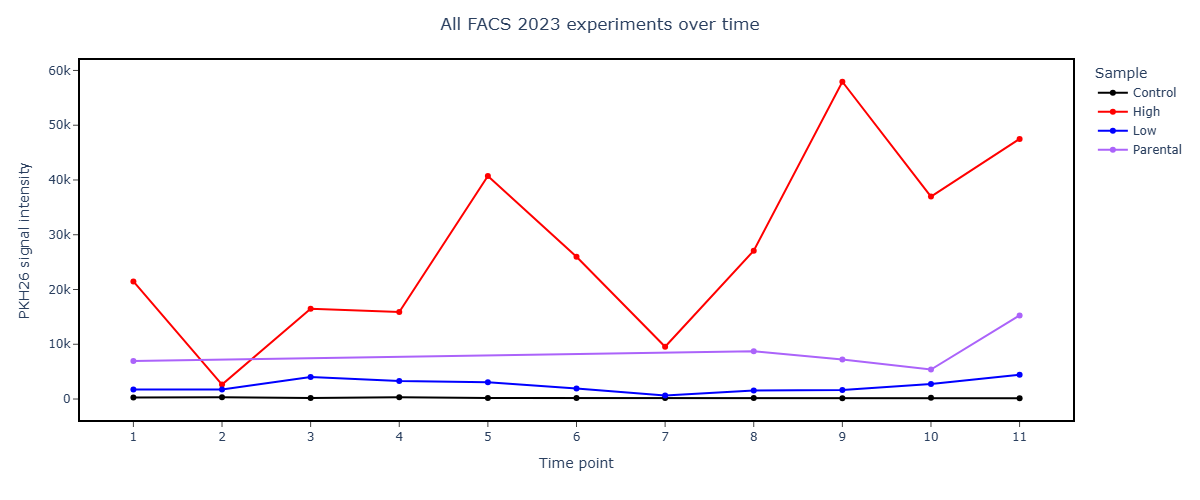

In [26]:
fig = px.line(
    medians, x="Time point" , y="PKH26", color="Sample", 
    color_discrete_map={"Control": "black", "Low": "blue", "High": "red"}, 
    markers=True
)

# Make a box around the figure and define the range of x and y axes.
fig.update_xaxes(
    showline=True, linewidth=2, linecolor='black', 
    mirror=True, 
    ticks="outside", 
    title_text="Time point", 
    tick0= 1, dtick=1
)
fig.update_yaxes(
    showline=True, linewidth=2, linecolor='black', 
    mirror=True, 
    ticks="outside", 
    title_text="PKH26 signal intensity"
)

fig.update_layout(
    plot_bgcolor="white", 
    title=dict(text="All FACS 2023 experiments over time", 
    x=0.5
    ),
    height=500, width=1200,
)

# Export the cleaned data

In [ ]:
export_path = r"YOUR_EXPORT_PATH\FACS_single cell data.xlsx"
df.to_excel(export_path, index=False)